# Initial Imports and Constants

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os

In [162]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [163]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 5*2* 0.0416667 # 1 hour to days

In [164]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [165]:
TOI_id = 'TOI 216'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)


SearchResult containing 38 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120    55652896      0.0
  1 TESS Sector 02 2018   SPOC     120    55652896      0.0
  2 TESS Sector 03 2018   SPOC     120    55652896      0.0
  3 TESS Sector 04 2018   SPOC     120    55652896      0.0
  4 TESS Sector 05 2018   SPOC     120    55652896      0.0
  5 TESS Sector 06 2018   SPOC     120    55652896      0.0
  6 TESS Sector 07 2019   SPOC     120    55652896      0.0
  7 TESS Sector 08 2019   SPOC     120    55652896      0.0
  8 TESS Sector 09 2019   SPOC     120    55652896      0.0
...            ...  ...    ...     ...         ...      ...
 28 TESS Sector 66 2023   SPOC     120    55652896      0.0
 29 TESS Sector 62 2023   SPOC     120    55652896      0.0
 30 TESS Sector 64 2023   SPOC     120    55652896      0

In [166]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 38 objects:
    0: <TessLightCurve LABEL="TIC 55652896" SECTOR=1 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 55652896" SECTOR=2 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 55652896" SECTOR=3 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 55652896" SECTOR=4 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 55652896" SECTOR=5 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 55652896" SECTOR=6 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 55652896" SECTOR=7 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 55652896" SECTOR=8 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 55652896" SECTOR=9 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 55652896" SECTOR=11 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 55652896" SECTOR=12 AUTHOR=S

In [167]:
clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [168]:
# Normalize, flatten, and remove outliers
processed_lcs = [
    lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
    for lc in clean_lcs
]

In [169]:
# Stitch into one combined light curve
combined_lc = processed_lcs[0]
for lc in processed_lcs[1:]:
    combined_lc = combined_lc.append(lc)



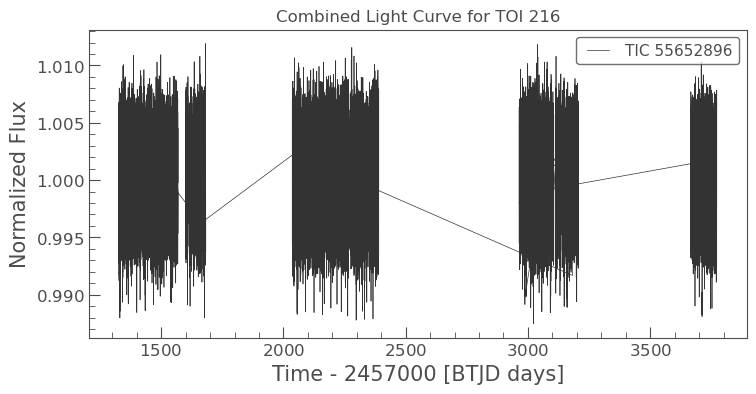

In [170]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [171]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1327.31399694 1327.31538585 1327.31677476 ... 3772.01147866 3772.01286754
 3772.01425642]
[1.004527   1.00061245 0.99753448 ... 1.00453794 1.00002416 0.99747423]


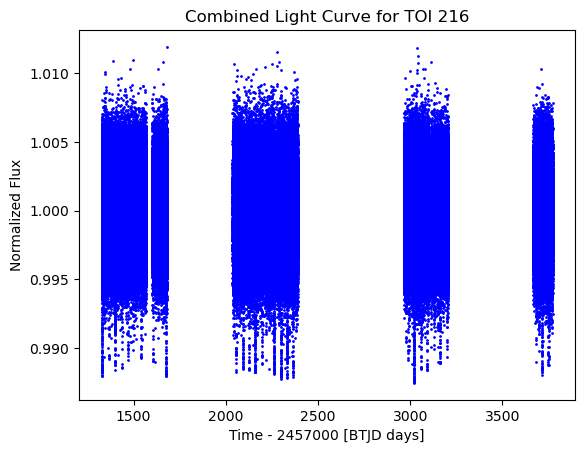

In [172]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 233085 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


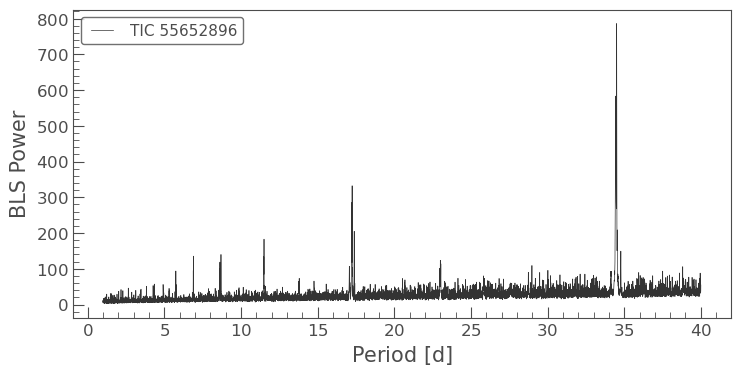

In [173]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1.0, 40, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [174]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")

Best candidate period: 34.50825 days
Best candidate t0: 1331.38900 days


In [175]:
import numpy as np
from scipy.signal import find_peaks

# 1. Access full power array
powers = bls_1.power.value
periods = bls_1.period.value
durations = bls_1.duration.value
t0s = bls_1.transit_time.value

# 2. Find all peaks in the BLS power spectrum
peaks, _ = find_peaks(powers)

# 3. Sort peaks by power (descending)
sorted_peaks = peaks[np.argsort(powers[peaks])[::-1]]

# 4. Get top 3 signal indices
top_indices = sorted_peaks[:7]

# 5. Extract their periods, durations, and t0s
top_periods = periods[top_indices]
top_durations = durations[top_indices]
top_t0s = t0s[top_indices]
top_powers = powers[top_indices]

# 6. Print results
for i in range(7):
    print(f"Signal {i+1}:")
    print(f"  Period:   {top_periods[i]:.5f} days")
    print(f"  T0:       {top_t0s[i]:.5f}")
    print(f"  Duration: {top_durations[i]:.5f} days")
    print(f"  Power:    {top_powers[i]:.5f}")
    print("-" * 30)


Signal 1:
  Period:   34.50825 days
  T0:       1331.38900
  Duration: 0.33000 days
  Power:    786.02028
------------------------------
Signal 2:
  Period:   34.44974 days
  T0:       1332.91900
  Duration: 0.20000 days
  Power:    583.08462
------------------------------
Signal 3:
  Period:   17.25293 days
  T0:       1331.42400
  Duration: 0.33000 days
  Power:    332.19407
------------------------------
Signal 4:
  Period:   17.22562 days
  T0:       1332.87900
  Duration: 0.20000 days
  Power:    284.93475
------------------------------
Signal 5:
  Period:   34.48485 days
  T0:       1331.94900
  Duration: 0.25000 days
  Power:    284.65068
------------------------------
Signal 6:
  Period:   34.55116 days
  T0:       1331.27900
  Duration: 0.25000 days
  Power:    208.66164
------------------------------
Signal 7:
  Period:   17.38944 days
  T0:       1332.31900
  Duration: 0.05000 days
  Power:    204.76526
------------------------------


In [176]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

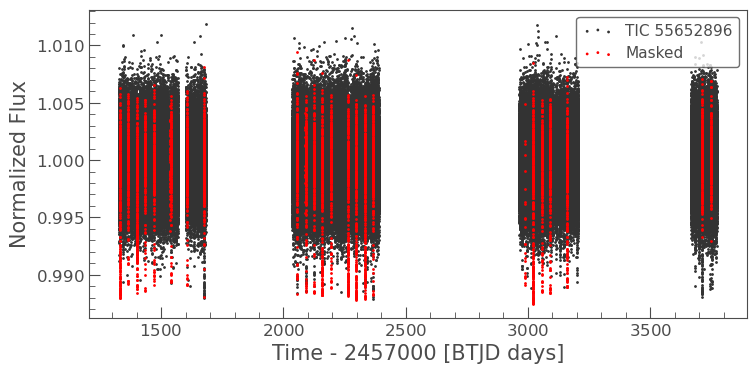

In [177]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [178]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


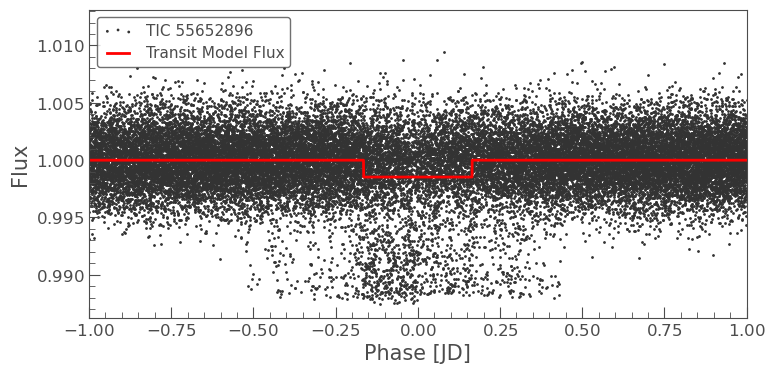

In [179]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 227109 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


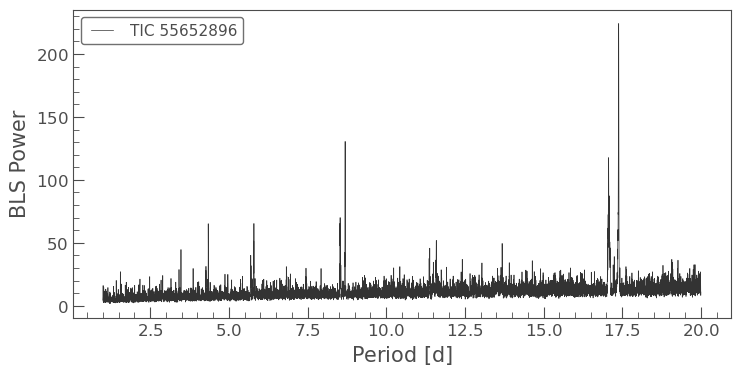

In [180]:
period = np.linspace(1, 20, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [181]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 17.38914 days
Best candidate t0 2: 1332.33900 days


In [182]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [183]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

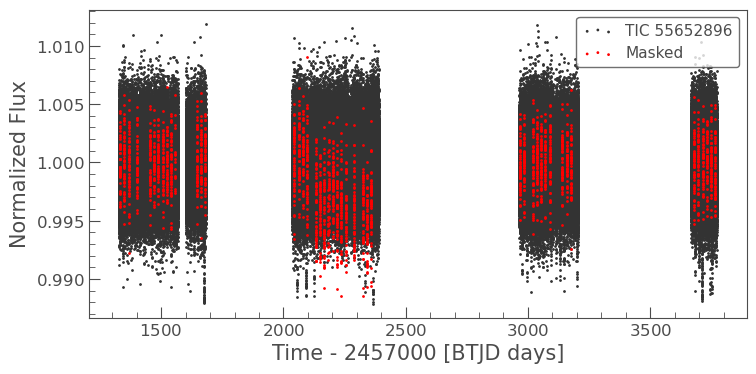

In [184]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [185]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

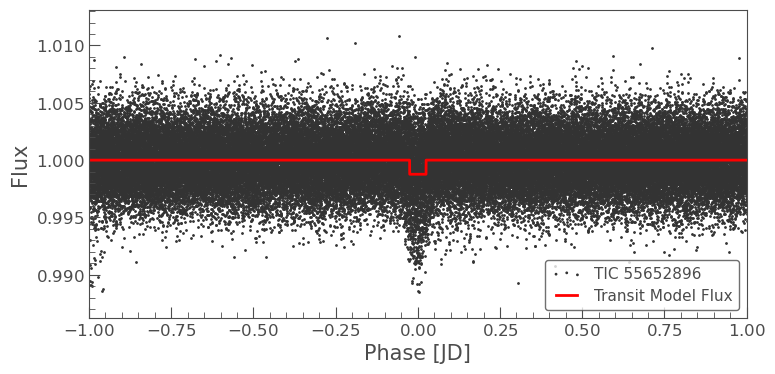

In [186]:
ax = combined_lc.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

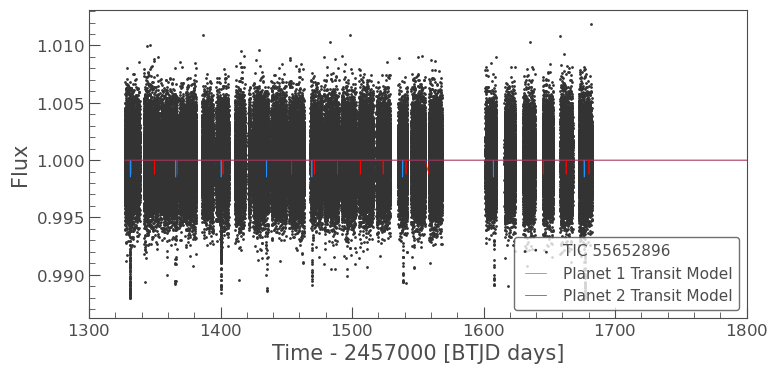

In [187]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
plt.xlim(1300,1800)
# plt.ylim(0.998,1.002)
plt.show()


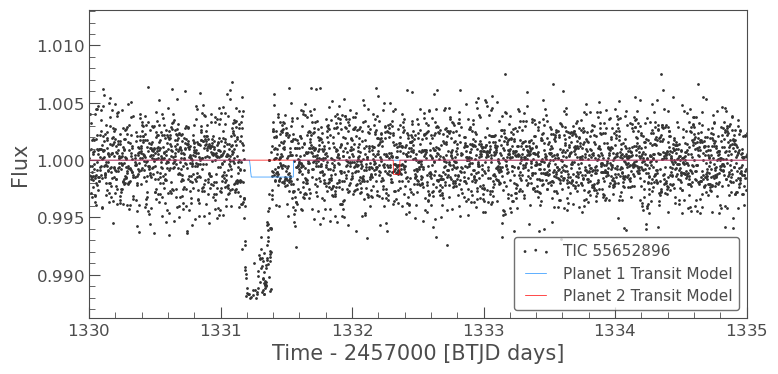

In [188]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');

plt.xlim(1330,1335)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [189]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = planet_1_model.time.value[peaks_1]
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_1, fluxes_1):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
transit_times_1 = np.sort(transit_times_1)
print(transit_times_1)

Planet 1 transit dip times and depths:
[1331.42377254 1365.98521618 1400.40617987 1434.82411034 1469.33208995
 1538.38955382 1607.45325809 1676.47059844 2056.06227582 2090.56263293
 2125.05030125 2159.55993717 2194.00961904 2263.14623067 2297.66680724
 2332.13345756 2366.64758867 2987.62651067 3022.32760979 3056.88450082
 3091.22497673 3160.26187814 3712.4577432  3746.86989927]


In [190]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = planet_2_model.time.value[peaks_2]
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
transit_times_2 = np.sort(transit_times_2)
print(transit_times_2)
print(len(transit_times_2))

Planet 2 transit dip times and depths:
[1332.33906147 1349.72674747 1367.11716575 1401.89645928 1454.06282089
 1471.45150925 1488.84016594 1506.23020549 1523.61471282 1541.00758208
 1558.41717055 1645.34245204 1662.73154087 1680.12064103 2045.2926985
 2062.68179539 2080.07087346 2097.45990574 2132.23919522 2149.6280484
 2167.01683256 2184.40555609 2201.79562967 2219.18429227 2236.57294299
 2253.96299445 2288.74046084 2323.51955437 2340.90850346 2358.29750781
 2966.91705976 2984.30711144 3019.0845758  3036.47338855 3053.86365336
 3071.25261248 3088.64162368 3140.80885606 3158.19796432 3175.58703945
 3679.87205725 3697.26071564 3714.65076998 3732.03946326 3749.42822083
 3766.81843331]
46


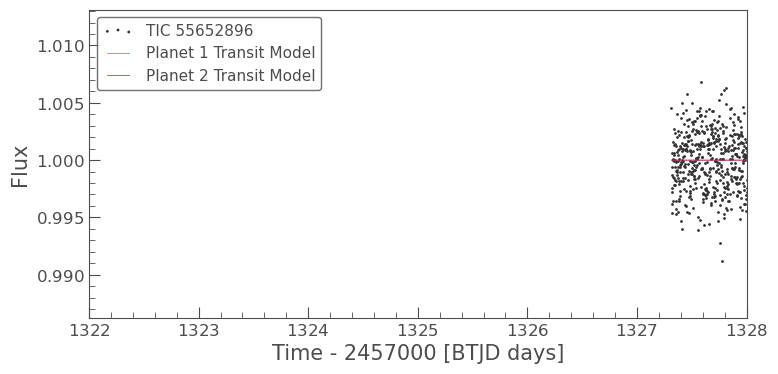

In [222]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');

tc_test = 1325
min_lim = tc_test - 3
max_lim = tc_test + 3
plt.xlim(min_lim,max_lim)
# plt.ylim(0.998,1.002)
plt.show()

In [192]:
valid_transit_2 = [transit_times_2[14], transit_times_2[15], transit_times_2[16], transit_times_2[17], 
                   transit_times_2[18], transit_times_2[19], transit_times_2[20], transit_times_2[21],
                   transit_times_2[23], transit_times_2[24], transit_times_2[25], transit_times_2[26],
                   transit_times_2[27], transit_times_2[28], transit_times_2[29]]

In [193]:
# # ### remove transit times that are too close to planet 1 
# threshold = 2.
# # Use broadcasting to calculate all absolute time differences
# diff_matrix = np.abs(transit_times_2[:, None] - transit_times_1[None, :])

# # Find which planet 2 transits are too close to any planet 1 transit
# too_close = np.any(diff_matrix < threshold, axis=1)

# # Keep only those that are not too close
# filtered_t2 = transit_times_2[~too_close]

# # Print results
# print(filtered_t2)
# transit_times_2 = filtered_t2

transit_times_2 = np.array(valid_transit_2)
print(transit_times_2)

[2045.2926985  2062.68179539 2080.07087346 2097.45990574 2132.23919522
 2149.6280484  2167.01683256 2184.40555609 2219.18429227 2236.57294299
 2253.96299445 2288.74046084 2323.51955437 2340.90850346 2358.29750781]


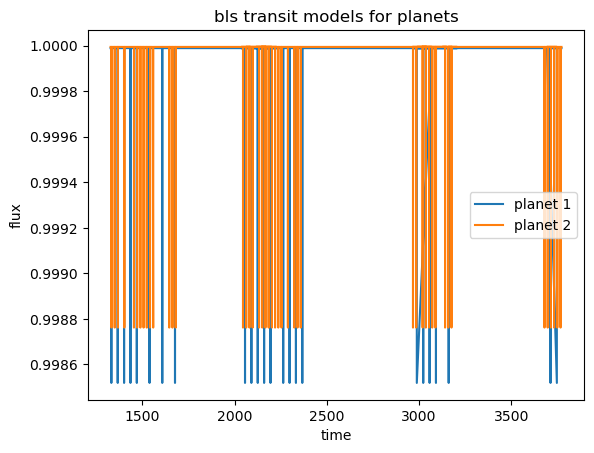

In [194]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [195]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [196]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [197]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        ### fit parabola to the chisq
        p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        ### Extract the coefficients   y = ax^2 + bx + c
        a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        ### Calculate the minimum chi-squared value
        chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        tc_chi_parabola[j] = tc_best_fit
    
        ### Calculate the parabola best fit 
        p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        ### calculate ttv from parabola fit 
        ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # # Find the intersection using root_scalar
        # intersections = []
        # for k in range(len(tc1) - 1):
        #     if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections.append((sol.root - min_chi_time))
        # errors.append(intersections)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()
    return tc_chi, ttv

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux
    
        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [199]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [200]:
### stellar params
q1 = 0.44
q2 = 0.24

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
# Mckee 2023
u1 = 0.48
u2 = 0.04
print(u1)
print(u2)

0.48
0.04


## Planet 1

In [201]:
### Planet params 
# from McKee 2023
per_1= 34.5508 
# per_1 = planet_1_period.value
rp_1= 0.09  # I MODIFIED THIS TO VISUALLY FIT DATA BETTER 
b_1= 0.19
T14_1= 5.514 * 0.0416667  # convert to days from hours


In [202]:
ttv_hour = 10*2* 0.0416667
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [203]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []

In [204]:
tc_chi_1, ttv_1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipyker

In [205]:
print(tc_chi_1)

[1331.28279811 1365.82589006 1400.3686423  1434.92337635 1469.47640104
 1538.59225668 1607.70767939 1676.80843655 2056.35173217 2090.81038088
 2125.26968747 2159.71926329 2194.16560849 2263.05864301 2297.51081779
 2331.95744807 2366.40985074 2987.65070155 3022.20665541 3056.75854143
 3091.31089605 3160.39951588 3712.09821672 3746.54540785]


In [206]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

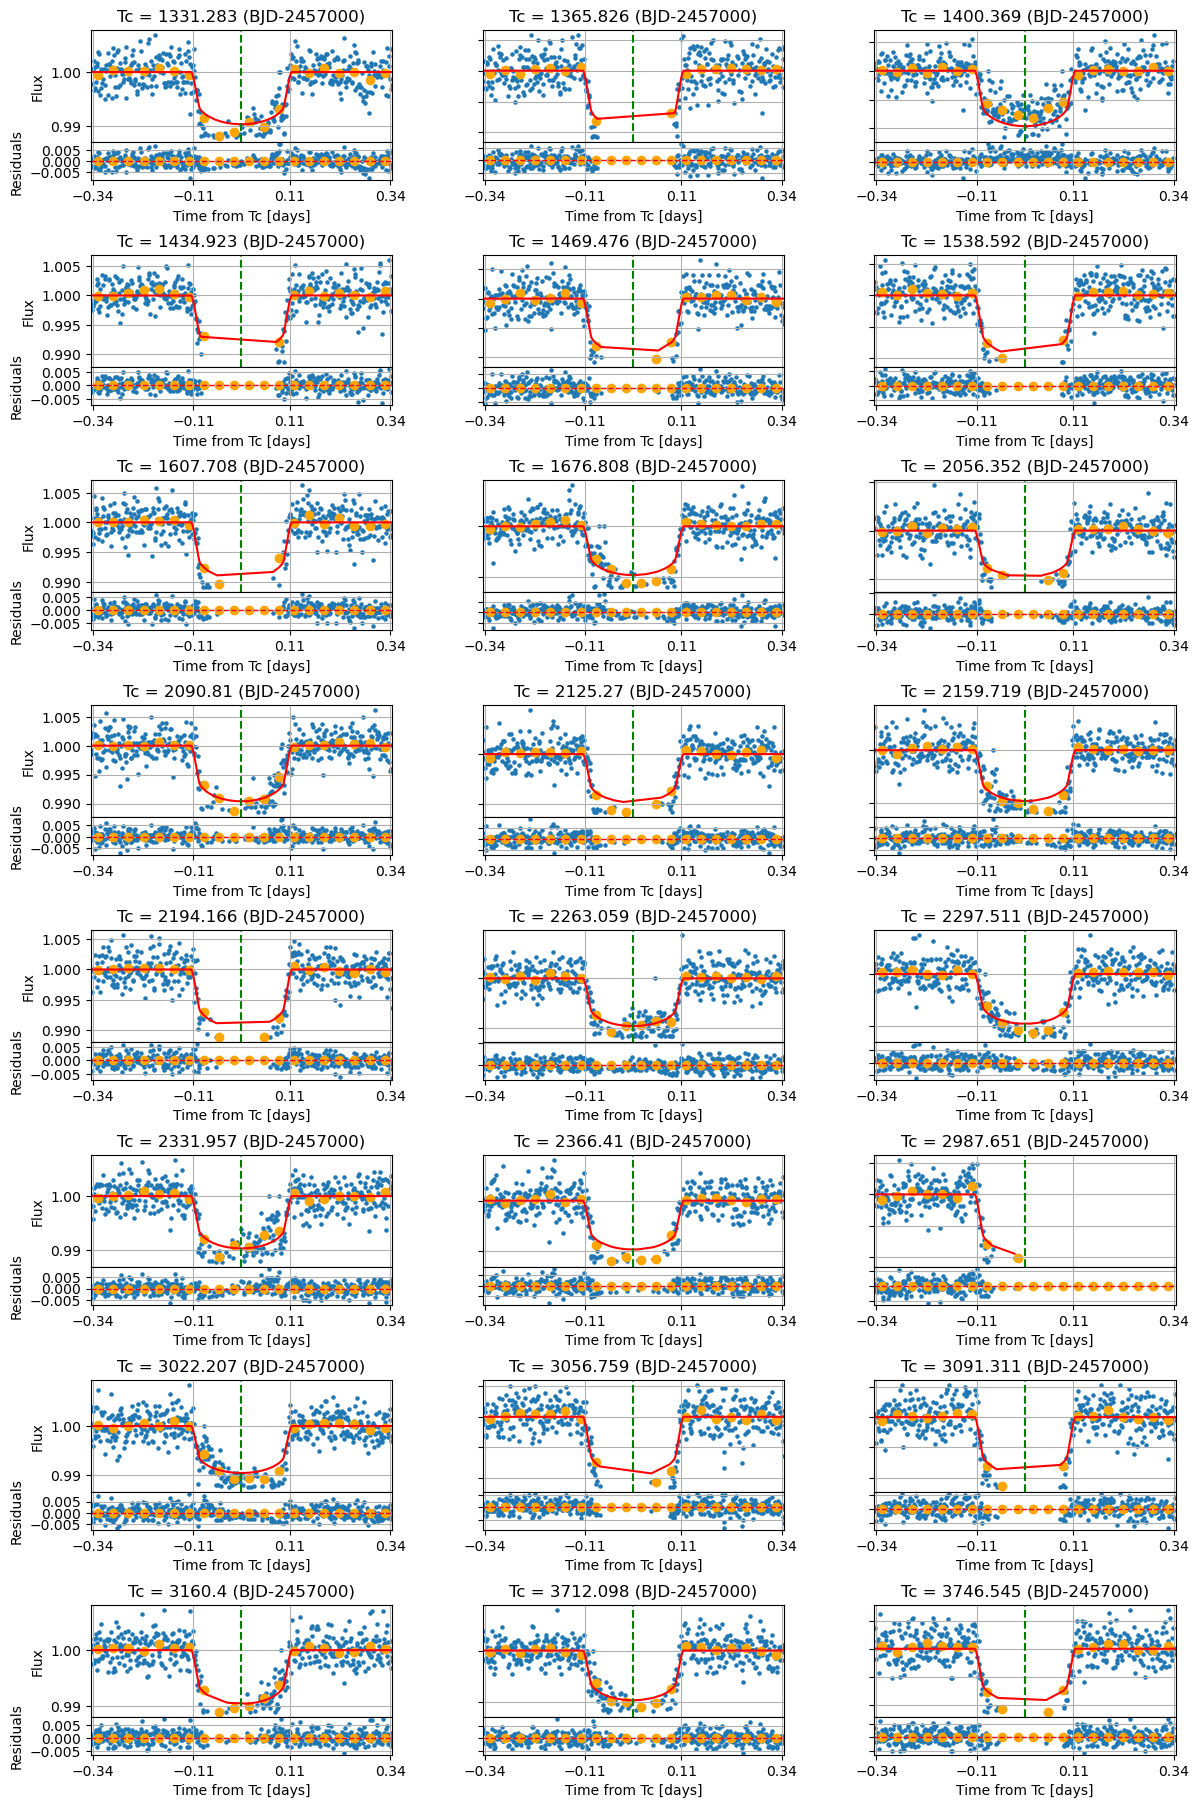

In [207]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

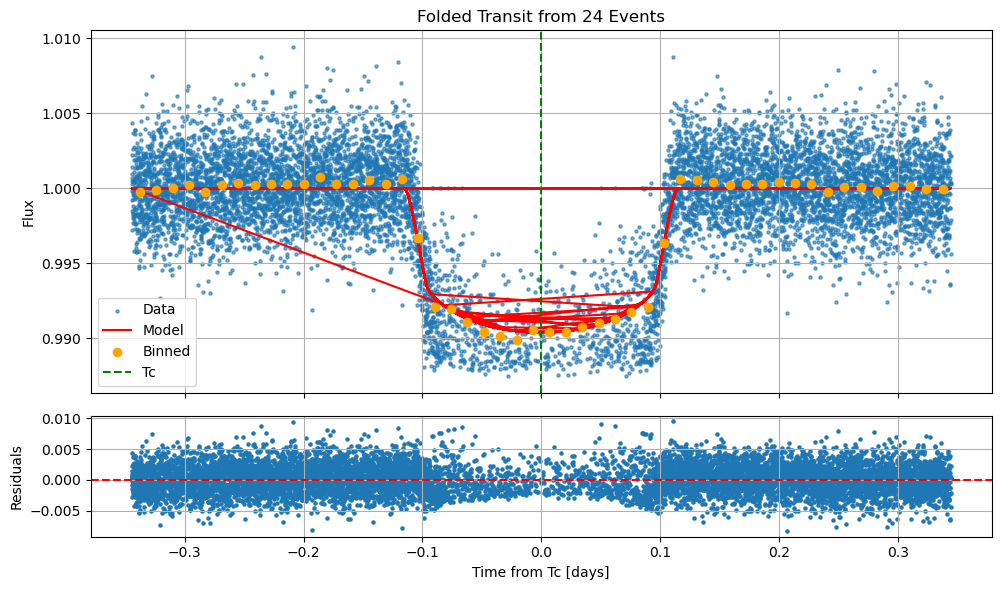

In [208]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer)

## Planet 2

In [209]:
### Planet params (from kipping et al 2019)
# planet b
per_2= 17.089
# per_2 = planet_2_period.value
rp_2= 0.0833
b_2= 0.948
T14_2= 2.062 * 0.0416667  # convert to days from hours


In [210]:
ttv_hour = 25*2* 0.0416667
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [211]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []

In [212]:
tc_chi_2, ttv_2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73604/295189538.py:59: RankWarning: Polyfit may be poorly conditioned
  p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipyker

In [213]:
print(tc_chi_2)

[2045.46161755 2062.80066435 2080.15220486 2097.51204125 2132.24128064
 2149.62596298 2167.00640545 2184.39512899 2219.17803601 2236.56251589
 2253.96507987 2288.75088794 2323.52163979 2340.90641804 2358.2870807 ]


In [214]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

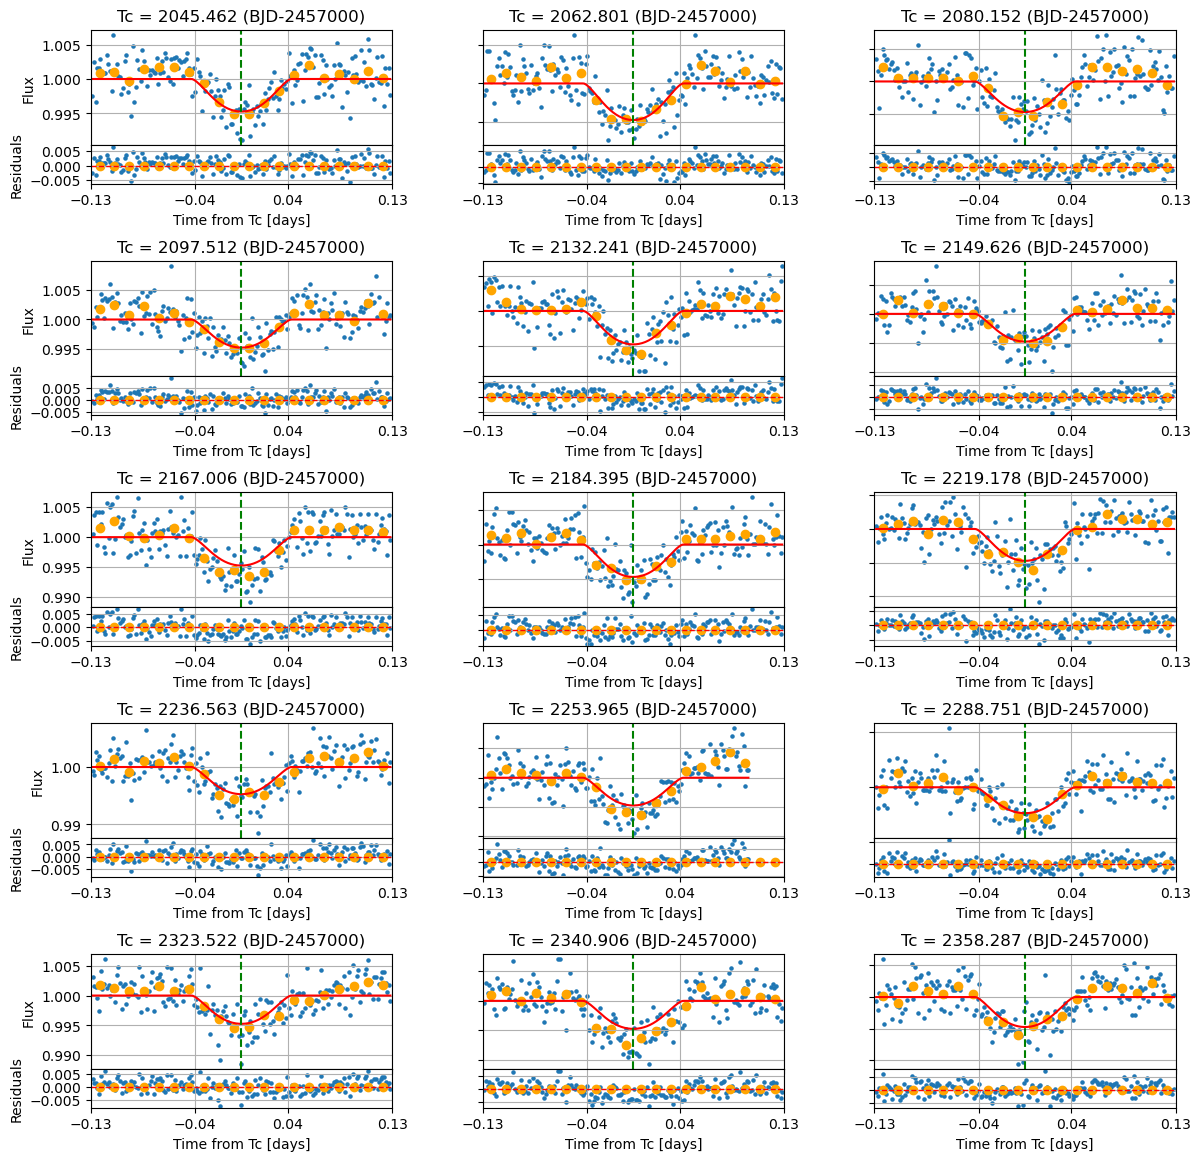

In [215]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

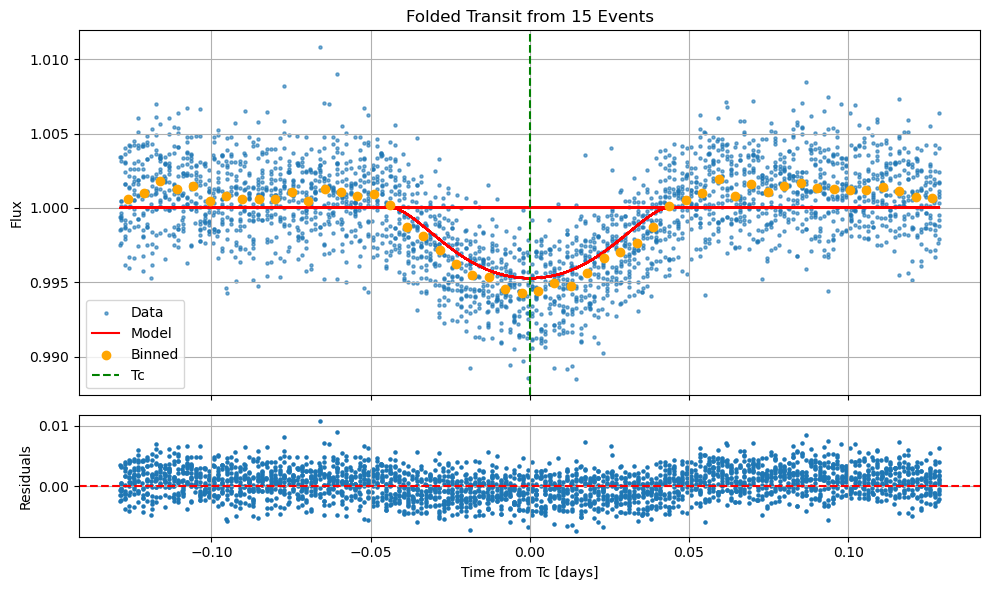

In [216]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer)

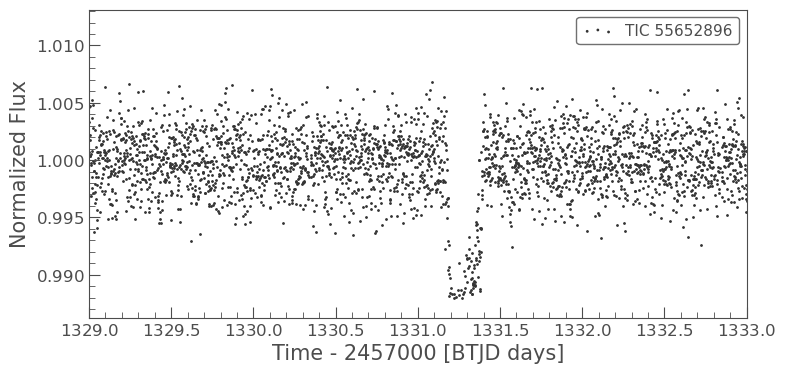

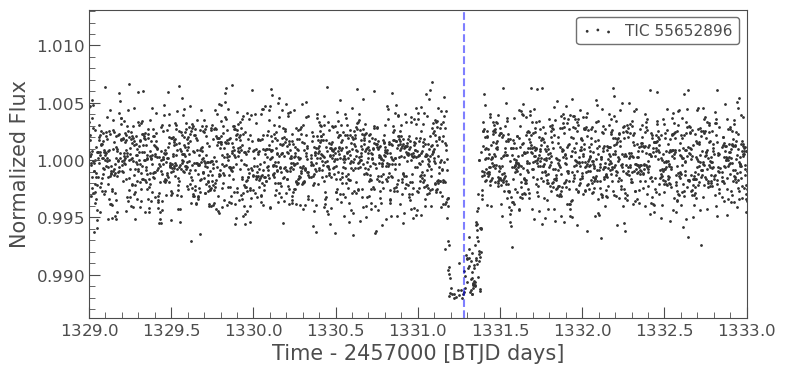

In [217]:
ax = combined_lc.scatter()
# for time in transit_times_1:
#     plt.axvline(x=time, color='b', linestyle='--')
# for time in transit_times_2:
#     plt.axvline(x=time, color='orange', linestyle='--')
# plt.xlim(1300, 1700)
plt.xlim(1329, 1333)
plt.show()

ax = combined_lc.scatter()
for time in transit_times_1:
    plt.axvline(x=time, color='b', linestyle='--', alpha=0.5)
for time in transit_times_2:
    plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5)
# plt.xlim(1300, 1700)
plt.xlim(1329, 1333)
plt.show()

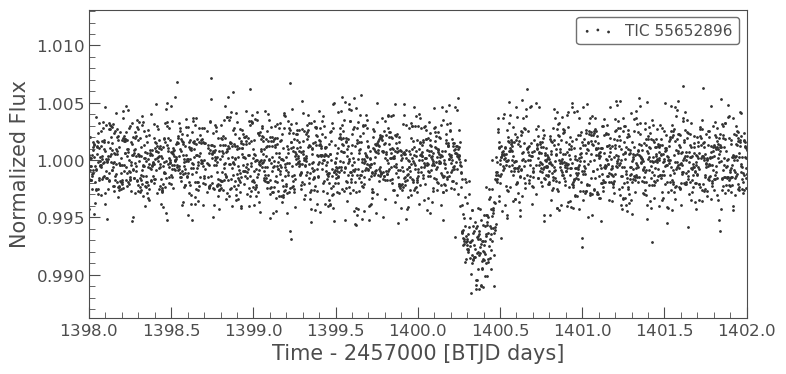

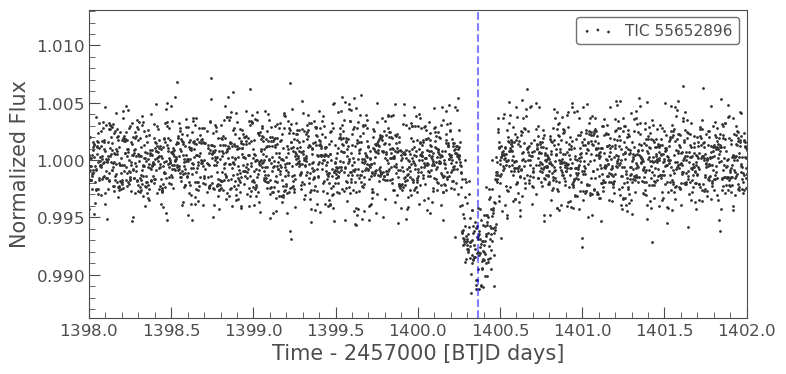

In [218]:
ax = combined_lc.scatter()
# for time in transit_times_1:
#     plt.axvline(x=time, color='b', linestyle='--')
# for time in transit_times_2:
#     plt.axvline(x=time, color='orange', linestyle='--')
# plt.xlim(1300, 1700)
plt.xlim(1398, 1402)
plt.show()

ax = combined_lc.scatter()
for time in transit_times_1:
    plt.axvline(x=time, color='b', linestyle='--', alpha=0.5)
for time in transit_times_2:
    plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5)
# plt.xlim(1300, 1700)
plt.xlim(1398, 1402)
plt.show()

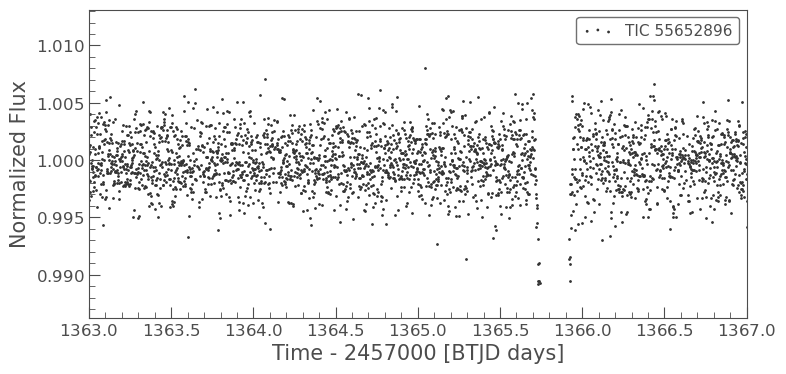

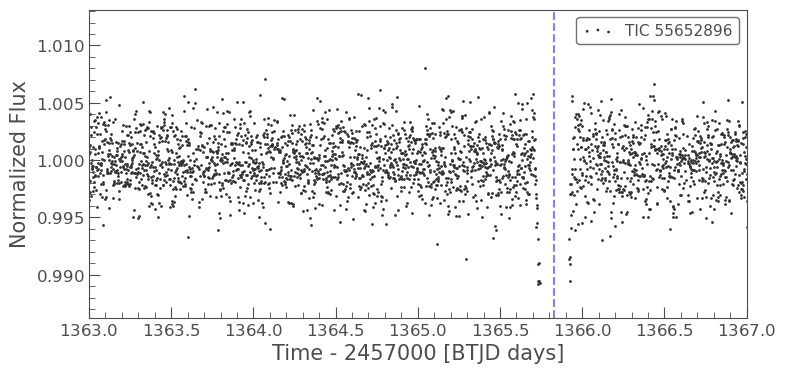

In [219]:
ax = combined_lc.scatter()
# for time in transit_times_1:
#     plt.axvline(x=time, color='b', linestyle='--')
# for time in transit_times_2:
#     plt.axvline(x=time, color='orange', linestyle='--')
# plt.xlim(1300, 1700)
plt.xlim(1363, 1367)
plt.show()

ax = combined_lc.scatter()
for time in transit_times_1:
    plt.axvline(x=time, color='b', linestyle='--', alpha=0.5)
for time in transit_times_2:
    plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5)
# plt.xlim(1300, 1700)
plt.xlim(1363, 1367)
plt.show()

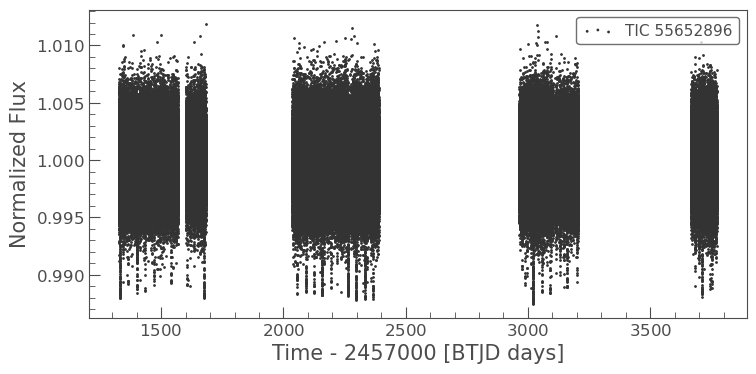

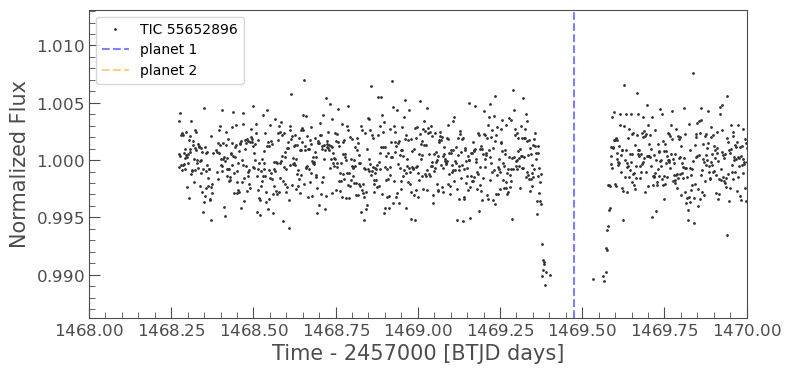

In [220]:
ax = combined_lc.scatter()
# for time in transit_times_1:
#     plt.axvline(x=time, color='b', linestyle='--')
# for time in transit_times_2:
#     plt.axvline(x=time, color='orange', linestyle='--')
# plt.xlim(1300, 1700)
# plt.xlim(2900, 3300)
plt.show()

ax = combined_lc.scatter()
for time in transit_times_1:
    # plt.axvline(x=time, color='b', linestyle='--', alpha=0.5)
    if time == transit_times_1[0]:
        plt.axvline(x=time, color='b', linestyle='--', alpha=0.5, label='planet 1')
    else:
        plt.axvline(x=time, color='b', linestyle='--', alpha=0.5)
for time in transit_times_2:
    # plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5)
    if time == transit_times_2[0]:
        plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5, label='planet 2')
    else:
        plt.axvline(x=time, color='orange', linestyle='--', alpha=0.5)
# plt.xlim(1300, 1700)
plt.xlim(1468, 1470)
plt.legend()
plt.show()

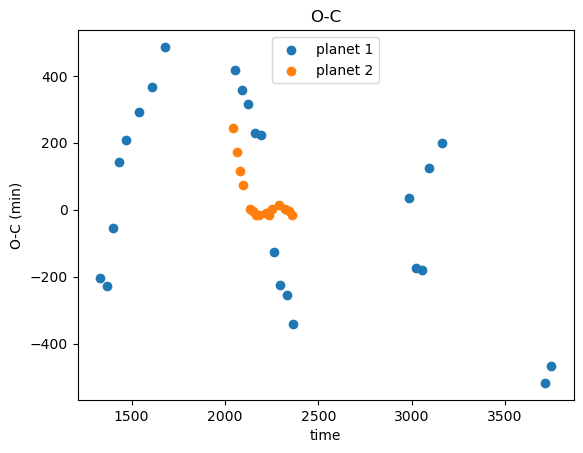

In [221]:
# TTV
plt.scatter(tc_chi_1, ttv_1*(24*60), label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60), label=f'planet 2 P~{round(planet_2_period.value, 3)}')
plt.title('O-C')
plt.xlabel('time')
plt.ylabel('O-C (min)')
# plt.ylim(-0.1,0.1)
plt.legend(loc='upper center')
plt.show()